## Objective
Replace the BatchNorm head (experiment 03) with a Linear → ReLU → Dropout(0.5) → Linear
head to test whether stochastic regularisation outperforms batch normalisation when
training DenseNet-121 from scratch on this dataset.
 
## Architecture Changes
 
| Component | 03. BatchNorm Weighted | 04. Dropout Weighted |
|---|---|---|
| Pretrained | False | False |
| Frozen backbone | False | False |
| Hidden dim | 256 | 256 |
| Head structure | Linear → BN → ReLU → Linear | **Linear → ReLU → Dropout → Linear** |
| Dropout | 0.0 | **0.5** |
| Pos weight | enabled | enabled |
| Optimiser | AdamW | AdamW |
| Weight decay | 1e-4 | 1e-4 |
| LR | 1e-3 | 1e-3 |
| Epochs | 30 | 30 |
 
## Hypothesis
BatchNorm reduces internal covariate shift but does not regularise by dropping units.
Dropout at 0.5 prevents co-adaptation of hidden neurons, which may reduce overfitting
on the training set and generalise better to the validation/test sets. Keeping
hidden_dim=256 allows a direct like-for-like comparison with experiment 03.
 

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
 
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))
 
from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.densenet import get_densenet121
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
 
import pandas as pd
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 
set_seed(42)
 
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
 
_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)
 
train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_densenet121(
    num_classes=1,
    pretrained=False,
    freeze_backbone=False,
    dropout=0.5,
    hidden_dim=256,
).to(device)
 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
 
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
 
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print('Pretrained: False | Frozen: False | Dropout: 0.5 | Hidden dim: 256 | Head: Linear → ReLU → Dropout → Linear')

Trainable params: 7,216,513 / 7,216,513
Pretrained: False | Frozen: False | Dropout: 0.5 | Hidden dim: 256 | Head: Linear → ReLU → Dropout → Linear


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []
 
for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)
 
    scheduler.step()
 
    train_history.append(train_metrics)
    val_history.append(val_metrics)
 
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")
 
    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/densenet121_dropout_weighted_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/30]
  Train | Loss: 1.1933, Bal Acc: 0.6015, Recall: 0.6579, F2: 0.3941, AUC: 0.6479
  Val   | Loss: 1.4772, Bal Acc: 0.6556, Recall: 0.5169, F2: 0.4254, AUC: 0.7131
  -> Saved best model (val AUC: 0.7131)


Epoch [2/30]
  Train | Loss: 1.1070, Bal Acc: 0.6778, Recall: 0.7309, F2: 0.4700, AUC: 0.7165
  Val   | Loss: 1.0668, Bal Acc: 0.6919, Recall: 0.8178, F2: 0.5044, AUC: 0.7461
  -> Saved best model (val AUC: 0.7461)


Epoch [3/30]
  Train | Loss: 1.0618, Bal Acc: 0.6858, Recall: 0.7982, F2: 0.4833, AUC: 0.7308
  Val   | Loss: 0.9821, Bal Acc: 0.7321, Recall: 0.8390, F2: 0.5464, AUC: 0.7873
  -> Saved best model (val AUC: 0.7873)


Epoch [4/30]
  Train | Loss: 1.0236, Bal Acc: 0.7057, Recall: 0.8198, F2: 0.5040, AUC: 0.7611
  Val   | Loss: 0.9671, Bal Acc: 0.7349, Recall: 0.9195, F2: 0.5522, AUC: 0.7982
  -> Saved best model (val AUC: 0.7982)


Epoch [5/30]
  Train | Loss: 1.0161, Bal Acc: 0.7083, Recall: 0.8198, F2: 0.5067, AUC: 0.7661
  Val   | Loss: 1.0880, Bal Acc: 0.6742, Recall: 0.9110, F2: 0.4965, AUC: 0.7228


...

Epoch [26/30]
  Train | Loss: 0.8438, Bal Acc: 0.7723, Recall: 0.8575, F2: 0.5797, AUC: 0.8453
  Val   | Loss: 0.8590, Bal Acc: 0.7678, Recall: 0.9322, F2: 0.5873, AUC: 0.8509
  -> Saved best model (val AUC: 0.8509)


Epoch [27/30]
  Train | Loss: 0.8327, Bal Acc: 0.7706, Recall: 0.8518, F2: 0.5778, AUC: 0.8478
  Val   | Loss: 0.8583, Bal Acc: 0.7664, Recall: 0.9322, F2: 0.5857, AUC: 0.8505


Epoch [28/30]
  Train | Loss: 0.8407, Bal Acc: 0.7664, Recall: 0.8575, F2: 0.5724, AUC: 0.8457
  Val   | Loss: 0.8694, Bal Acc: 0.7585, Recall: 0.9364, F2: 0.5770, AUC: 0.8479


Epoch [29/30]
  Train | Loss: 0.8204, Bal Acc: 0.7770, Recall: 0.8712, F2: 0.5852, AUC: 0.8542
  Val   | Loss: 0.8639, Bal Acc: 0.7627, Recall: 0.9364, F2: 0.5816, AUC: 0.8486


Epoch [30/30]
  Train | Loss: 0.8444, Bal Acc: 0.7738, Recall: 0.8666, F2: 0.5813, AUC: 0.8475
  Val   | Loss: 0.8609, Bal Acc: 0.7649, Recall: 0.9280, F2: 0.5840, AUC: 0.8490


## Plot Train and Validation Curves

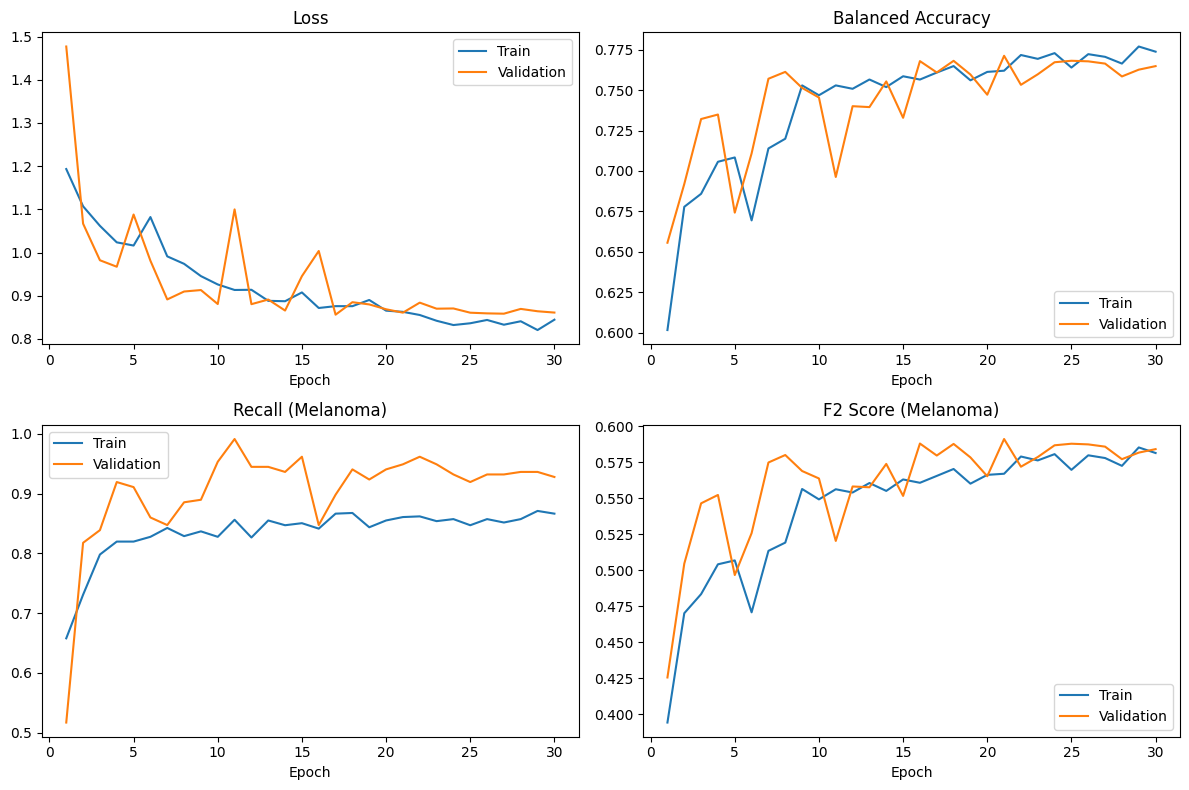

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/densenet121_dropout_weighted_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

C:\Users\1008462\AppData\Local\Temp\ipykernel_17160\1929282392.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(ROOT / 'models/densen

Best threshold: 0.56 | Val F2: 0.5953


## Test Set Evaluation

Threshold:          0.56
AUC-ROC:            0.8543
Balanced Accuracy:  0.7743
F2 Score:           0.5882

              precision    recall  f1-score   support

Non-Melanoma     0.9790    0.6597    0.7882      1340
    Melanoma     0.2500    0.8889    0.3902       171

    accuracy                         0.6856      1511
   macro avg     0.6145    0.7743    0.5892      1511
weighted avg     0.8965    0.6856    0.7432      1511



C:\Users\1008462\Desktop\50.021_project_group4\venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


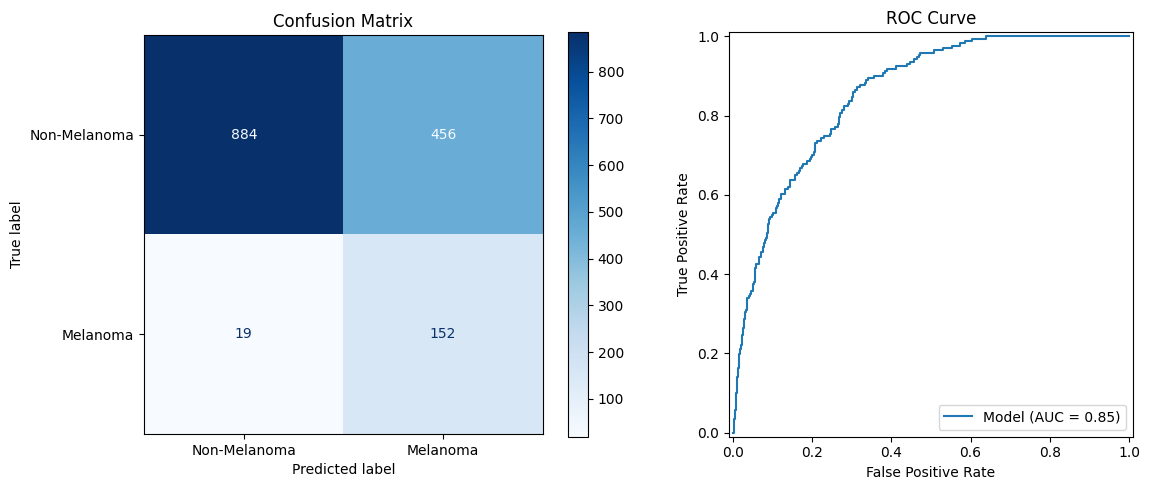

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)